In this notebook, I explore Convolutional Neural Networks (CNNs) for image classification.

The goal is to understand how CNNs extract spatial features from images, why they work better than traditional machine learning models on vision tasks, and how techniques like pooling and data augmentation help improve generalization.

I'll build a simple CNN from scratch, train it on an image dataset, check its performance, and look at how different architectural choices affect learning and overfitting.

### Import Required libraries


In [3]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#### Load the MNIST Data

The MNIST dataset consists of 70,000 grayscale images of handwritten digits (0–9), each with a resolution of 28×28 pixels.

It's a standard benchmark dataset for learning and experimenting with Convolutional Neural Networks because it's simple, well-structured, and lets us focus on understanding CNN concepts instead of dealing with messy data.

In [4]:
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


#### Inspect the data shape and Labels

Before preprocessing, it is important to inspect the structure of the dataset. This helps confirm the image dimensions, the number of samples, and the format of the labels.


In [5]:
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


#### Visualizing Sample Images

CNNs are designed to learn spatial patterns from images, so looking at a few samples helps confirm that the images loaded correctly, make sense, and match their labels. This step also shows why CNNs work better than traditional machine learning models for image tasks.

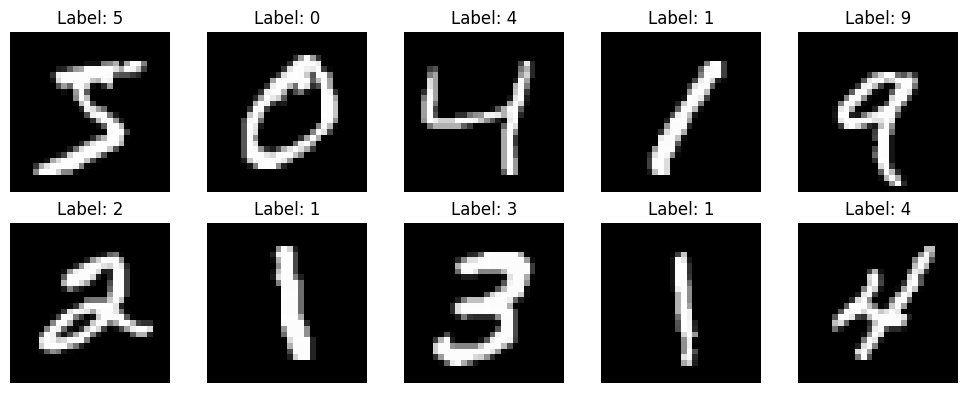

In [6]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

#### Data Preprocessing: Normalization and Reshaping

Before feeding images into a Convolutional Neural Network, we need to preprocess them in a way that makes training stable and efficient.

This involves two key steps:

1. Normalization: scaling pixel values from the range 0–255 to 0–1 so the network can learn more effectively.

In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

2. Reshaping – adding a channel dimension to the images, since CNNs expect input data in the format (height, width, channels).

In [8]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

Verify Processed Data shape

In [9]:
print("Training data shape after preprocessing:", X_train.shape)
print("Test data shape after preprocessing:", X_test.shape)

Training data shape after preprocessing: (60000, 28, 28, 1)
Test data shape after preprocessing: (10000, 28, 28, 1)


#### Building a simple Convolution Neural Network (CNN)


In this step, we build a simple Convolutional Neural Network from scratch.

The goal is not to build the most complex model, but to clearly understand how convolutional layers, pooling layers, and fully connected layers work together to perform image classification.

In [10]:
# Define the CNN model

model = models.Sequential([
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and fully connected layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

#### Compiling the CNN

Before training a neural network, we must compile it by specifying three key components:

Loss function – tells the model how wrong its predictions are

Optimizer – defines how the model updates its weights

Metrics – what we track to evaluate performance during training

Since this is a multi-class classification problem (digits 0 to 9), we use categorical probability outputs with the right loss function and accuracy as the evaluation metric.

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Training the CNN

The model is trained on the training dataset while monitoring its performance on a validation set.

The validation set allows us to observe how well the model generalizes to unseen data and helps detect overfitting early.

During training, the CNN adjusts its weights using backpropagation to minimize the loss and improve prediction accuracy

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.8662 - loss: 0.4380 - val_accuracy: 0.9800 - val_loss: 0.0707
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 78s 51ms/step - accuracy: 0.9801 - loss: 0.0665 - val_accuracy: 0.9838 - val_loss: 0.0565
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 52ms/step - accuracy: 0.9863 - loss: 0.0442 - val_accuracy: 0.9880 - val_loss: 0.0409
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.9906 - loss: 0.0310 - val_accuracy: 0.9880 - val_loss: 0.0417
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - accuracy: 0.9917 - loss: 0.0243 - val_accuracy: 0.9868 - val_loss: 0.0469


#### Evaluate the CNN on the test set

Up to this point, we’ve been monitoring training and validation performance.
However, both of those were seen during training.

The test set is completely untouched by the model.
Evaluating on it tells us how well the CNN truly generalizes to unseen data.

This is the most honest measure of real-world performance.

In [14]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9844 - loss: 0.0497
Test Accuracy: 0.988099992275238
Test Loss: 0.03836403787136078


Generate Predictions

In [15]:
import numpy as np

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


Classification Report

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.98      0.99      1032
           3       0.98      0.99      0.99      1010
           4       1.00      0.97      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.96      1.00      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



Confusion Matrix

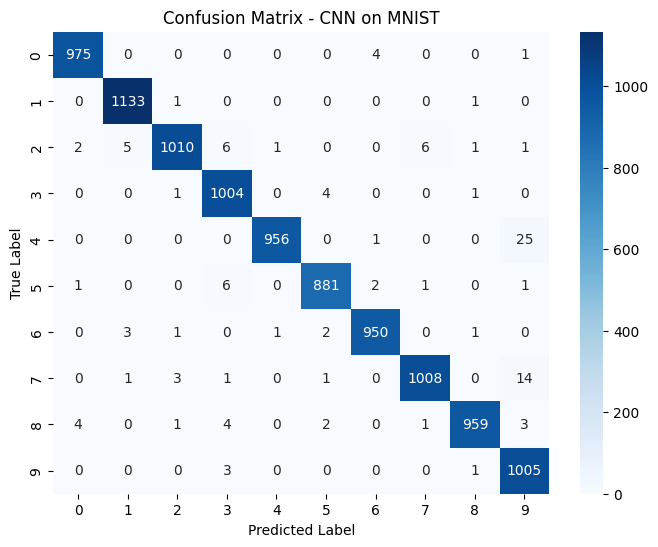

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CNN on MNIST")
plt.show()

## Conclusion

In this project, I built and trained a Convolutional Neural Network (CNN) to classify handwritten digits using the MNIST dataset. Starting from raw grayscale images, I went through data preprocessing, built the model with convolutional and pooling layers, trained it, validated it, and tested it on unseen data.

The CNN hit around 99% test accuracy, showing it can learn spatial patterns like edges, curves, and shapes directly from images. Unlike traditional machine learning models, the convolutional design keeps spatial relationships between pixels intact, which leads to better and more generalizable feature learning.

One key takeaway is how CNNs naturally reduce overfitting through their architecture and techniques like pooling and data augmentation. Instead of just using classical regularization methods like L1 or L2 penalties, data augmentation shows the model different versions of the same images, which improves generalization without changing the labels.

Overall, this shows why CNNs are the go-to approach for computer vision tasks and gives me a solid foundation for working with more advanced deep learning models in image classification.

In [18]:
model.save('mnist_cnn_model.h5')
print("Model saved successfully as 'mnist_cnn_model.h5'")

Model saved successfully as 'mnist_cnn_model.h5'


## Data Augmentation

#### Why Data Augmentation?

In real-world image tasks, models rarely see perfectly clean or identical images. Lighting, orientation, scale, and perspective often vary.
Data augmentation helps address this by artificially increasing the diversity of the training data through small, realistic transformations — without changing the image labels.

Instead of memorizing exact images, the CNN learns to recognize robust patterns (edges, shapes, textures), improving generalization and reducing overfitting.

#### Create an Image Generator

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [20]:
datagen = ImageDataGenerator(
    rotation_range=10,        # rotate images slightly
    width_shift_range=0.1,    # horizontal shifts
    height_shift_range=0.1,   # vertical shifts
    zoom_range=0.1            # random zoom
)

#### Fit the Generator on Training data

In [21]:
datagen.fit(X_train)

This is to allows the generator to learn the structure of the dataset before producing augmented samples.

#### Now train the CNN using augmented data

When training with data augmentation, Keras uses a generator that produces infinite variations of the training data. To properly track validation metrics per epoch, the number of steps per epoch must be specified explicitly.

In [22]:
steps_per_epoch = X_train.shape[0] // 64

history_aug = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    steps_per_epoch=steps_per_epoch,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
  1/937 ━━━━━━━━━━━━━━━━━━━━ 1:43 110ms/step - accuracy: 0.9062 - loss: 0.2173

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


937/937 ━━━━━━━━━━━━━━━━━━━━ 69s 73ms/step - accuracy: 0.9494 - loss: 0.1591 - val_accuracy: 0.9915 - val_loss: 0.0243
Epoch 2/5
  1/937 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 1.0000 - loss: 0.0222

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


937/937 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 1.0000 - loss: 0.0222 - val_accuracy: 0.9918 - val_loss: 0.0241
Epoch 3/5
937/937 ━━━━━━━━━━━━━━━━━━━━ 69s 73ms/step - accuracy: 0.9779 - loss: 0.0727 - val_accuracy: 0.9892 - val_loss: 0.0299
Epoch 4/5
937/937 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9688 - loss: 0.0774 - val_accuracy: 0.9891 - val_loss: 0.0298
Epoch 5/5
937/937 ━━━━━━━━━━━━━━━━━━━━ 68s 72ms/step - accuracy: 0.9821 - loss: 0.0581 - val_accuracy: 0.9906 - val_loss: 0.0257


After introducing data augmentation, the model maintained high validation accuracy (~99.2%) while keeping validation loss low and stable. This indicates improved generalization and reduced overfitting, as the model learned to recognize digits under small transformations rather than memorizing the training samples.

#### Save the model

In [23]:
model.save("mnist_cnn_augmented.keras")

In [24]:
## How to load the saved model
# from tensorflow.keras.models import load_model
# loaded_model = load_model('mnist_cnn_model.h5')
# print("Model loaded successfully.")

#### Conclusion

The final CNN model trained with data augmentation was saved using the native Keras format (.keras). This format stores the full model architecture and learned weights, allowing the model to be easily reloaded for inference, evaluation, or further training.

In [29]:
from google.colab import files
files.download("mnist_cnn_augmented.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>